In [1]:
# data.gov
# updated September 25, 2025


In [2]:
# import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Read CSV and review first few rows
# EDA

df = pd.read_csv('Complaint_indexes_and_policy_counts_for_insurance_companies.csv')
df.head()

,Organization ID,Company name,NAIC ID,Total number of confirmed complaints,Total policies,Complaint Index,Year of policy count,Line of coverage
0,75,GHS INSURANCE COMPANY,29718.0,0.0,4274,0.0,2019,Accident and Health
1,76,"STERLING NATIONAL LIFE INSURANCE COMPANY, INC.",91785.0,0.0,1108,0.0,2019,Accident and Health
2,79,AMERICAN NATIONAL LIFE INSURANCE COMPANY OF TEXAS,71773.0,0.0,8779,0.0,2019,Accident and Health
3,87,AMERICAN PUBLIC LIFE INSURANCE COMPANY,60801.0,0.0,7111,0.0,2019,Accident and Health
4,91,AMERICAN REPUBLIC INSURANCE COMPANY,60836.0,0.0,538,0.0,2019,Accident and Health


In [4]:
# Desriptive statistics of DataFrame
# EDA

df.describe()

,Organization ID,NAIC ID,Total number of confirmed complaints,Total policies,Complaint Index,Year of policy count
count,5584.000000,5432.000000,5582.000000,5.584000e+03,4326.000000,5584.000000
mean,18614.160100,49194.275221,1.676281,1.672906e+05,81.517379,2022.537966
std,36260.202893,27011.358530,12.343077,5.242908e+06,1680.761833,1.591102
min,75.000000,10030.000000,0.000000,1.000000e+00,0.000000,2019.000000
25%,1523.000000,22292.000000,0.000000,1.170000e+02,0.000000,2022.000000
50%,2850.500000,57626.000000,0.000000,1.494500e+03,0.000000,2023.000000
75%,13190.000000,69108.000000,0.000000,1.491525e+04,0.000000,2024.000000
max,208673.000000,99937.000000,381.000000,3.727562e+08,69205.350000,2024.000000


In [5]:
# Concise summary
# EDA

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5584 entries, 0 to 5583
Data columns (total 8 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Organization ID                       5584 non-null   int64  
 1   Company name                          5584 non-null   object 
 2   NAIC ID                               5432 non-null   float64
 3   Total number of confirmed complaints  5582 non-null   float64
 4   Total policies                        5584 non-null   int64  
 5   Complaint Index                       4326 non-null   float64
 6   Year of policy count                  5584 non-null   int64  
 7   Line of coverage                      5584 non-null   object 
dtypes: float64(3), int64(3), object(2)
memory usage: 349.1+ KB


In [6]:
# How many rows and columns
# EDA

print(df.shape)     # would not allow me to use df.shape only

(5584, 8)


In [7]:
# Checking for missing values
# EDA

df.isnull().sum()

Organization ID                            0
Company name                               0
NAIC ID                                  152
Total number of confirmed complaints       2
Total policies                             0
Complaint Index                         1258
Year of policy count                       0
Line of coverage                           0
dtype: int64

In [8]:
# View Columns names in the DataFrame since code would not recognize above columns
# EDA

print(df.columns)

Index(['Organization ID', 'Company name', 'NAIC ID',
       'Total number of confirmed complaints', 'Total policies',
       'Complaint Index', 'Year of policy count', 'Line of coverage'],
      dtype='object')


In [9]:
# Remove columns Organization ID and NAIC ID
# EDA

cols_to_drop = ['Organization ID', 'NAIC ID']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)
list(df.columns)

['Company name',
 'Total number of confirmed complaints',
 'Total policies',
 'Complaint Index',
 'Year of policy count',
 'Line of coverage']

In [10]:
# Rename some columns
# Data cleaning

df.rename(columns={
    'Total number of confirmed complaints': 'Total_Complaints',
    'Year of policy count': 'Year',
    'Line of coverage': 'Coverage_Type'
}, inplace=True)

list(df.columns)

['Company name',
 'Total_Complaints',
 'Total policies',
 'Complaint Index',
 'Year',
 'Coverage_Type']

In [11]:
# List all strings in the Company Name column
# Remove duplicates
# Data Cleaning

company_list = df['Company name'].dropna().unique().tolist()
print(company_list)

['GHS INSURANCE COMPANY', 'STERLING NATIONAL LIFE INSURANCE COMPANY, INC.', 'AMERICAN NATIONAL LIFE INSURANCE COMPANY OF TEXAS', 'AMERICAN PUBLIC LIFE INSURANCE COMPANY', 'AMERICAN REPUBLIC INSURANCE COMPANY', 'CELTIC INSURANCE COMPANY', 'CHRISTIAN FIDELITY LIFE INSURANCE COMPANY', 'COVENTRY HEALTH AND LIFE INSURANCE COMPANY', 'STANDARD LIFE AND CASUALTY INSURANCE COMPANY', 'AMERICAN INCOME LIFE INSURANCE COMPANY', 'CATLIN INSURANCE COMPANY, INC.', 'WILTON REASSURANCE LIFE COMPANY OF NEW YORK', 'AMERICAN NATIONAL INSURANCE COMPANY', 'AMERICAN FIDELITY ASSURANCE COMPANY', 'SAGICOR LIFE INSURANCE COMPANY', 'AMERICAN GENERAL LIFE INSURANCE COMPANY', 'AMERICAN HEALTH AND LIFE INSURANCE COMPANY', 'AMERICAN HERITAGE LIFE INSURANCE COMPANY', 'AMERICAN HOME ASSURANCE COMPANY', 'AMERICAN HOME LIFE INSURANCE COMPANY, THE', 'ALLSTATE LIFE INSURANCE COMPANY', 'AMERICAN BANKERS LIFE ASSURANCE COMPANY OF FLORIDA', 'AETNA HEALTH AND LIFE INSURANCE COMPANY', 'THRIVENT FINANCIAL FOR LUTHERANS', 'AAA LI

In [12]:
# View Coverage Type
# EDA

df['Coverage_Type'].unique()

array(['Accident and Health', 'Automobile', 'Homeowners',
       'Life and Annuity', "Workers' Compensation"], dtype=object)

In [13]:
# Assign an integer to Coverage Type
# Feature Engineering

mapping = {
    "Accident and Health": 1,
    "Automobile": 2,
    "Homeowners": 3,
    "Life and Annuity": 4,
    "Worker's Compensation": 5
    
}
print(mapping)

{'Accident and Health': 1, 'Automobile': 2, 'Homeowners': 3, 'Life and Annuity': 4, "Worker's Compensation": 5}


C:\Users\shopr\AppData\Local\Temp\ipykernel_29704\764551180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Coverage_Type', y='Total_Complaints', data=df, jitter=True, alpha=0.6, palette='Set2')


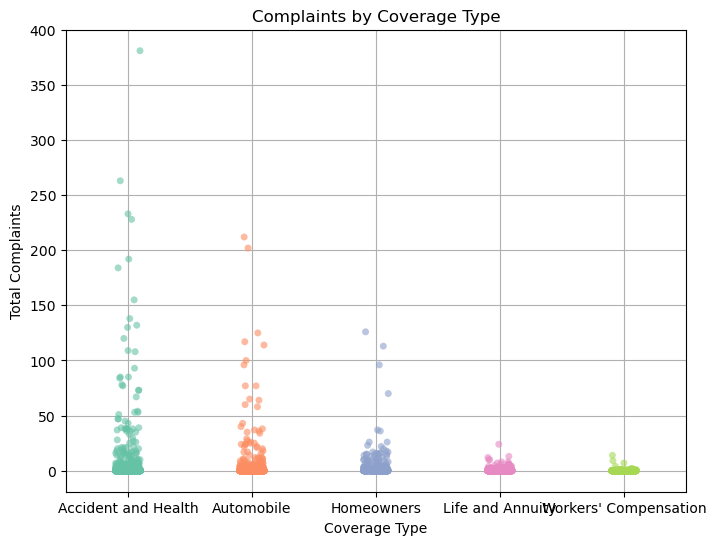

In [14]:
#  Scatter plot is seaborn for Coverage Type and Total Complaints
# EDA

plt.figure(figsize=(8, 6))
sns.stripplot(x='Coverage_Type', y='Total_Complaints', data=df, jitter=True, alpha=0.6, palette='Set2')
plt.title('Complaints by Coverage Type')
plt.xlabel('Coverage Type')
plt.ylabel('Total Complaints')
plt.grid(True)
plt.show()


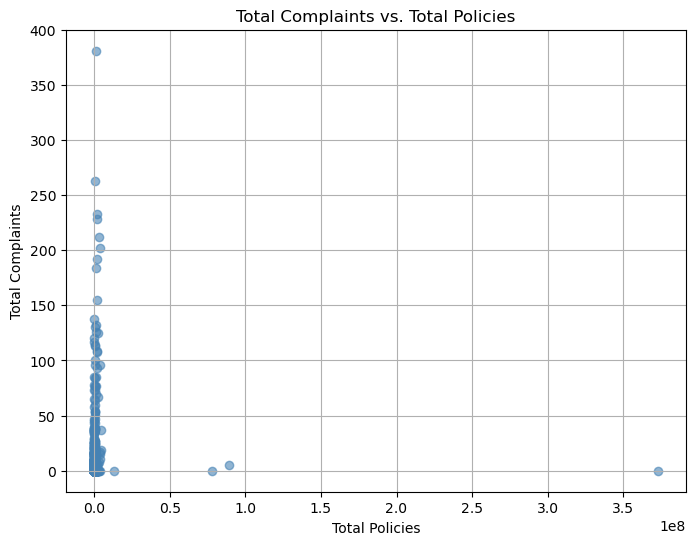

In [15]:
# Scatter plot for Total policies and Total Complaints
# EDA

plt.figure(figsize=(8, 6))
plt.scatter(df['Total policies'], df['Total_Complaints'], alpha=0.6, c='steelblue')
plt.xlabel('Total Policies')
plt.ylabel('Total Complaints')
plt.title('Total Complaints vs. Total Policies')
plt.grid(True)
plt.show()
            
# le8 means 100 million or 1 * 10 to the 8th power

In [16]:
# Complaint Index and Total Complaints Correlation
# Statistical Analysis

subset = df[['Complaint Index', 'Total_Complaints']]
correlation_matrix = subset.corr()
print(correlation_matrix)

                  Complaint Index  Total_Complaints
Complaint Index           1.00000           0.00066
Total_Complaints          0.00066           1.00000


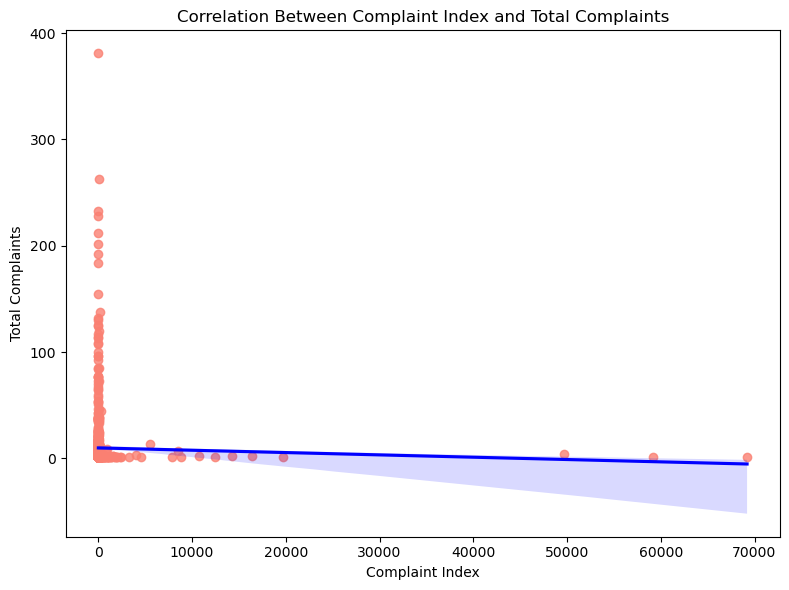

In [17]:
# Plot Correlation

# Filter out rows with missing or zero values in both columns
corr_df = df[
    df['Total_Complaints'].notna() &
    df['Complaint Index'].notna() &
    (df['Total_Complaints'] != 0) &
    (df['Complaint Index'] != 0)
]

# Scatterplot with regression line
plt.figure(figsize=(8, 6))
sns.regplot(
    x='Complaint Index',
    y='Total_Complaints',
    data=corr_df,
    scatter_kws={'color': 'salmon'},
    line_kws={'color': 'blue'}
)

plt.title('Correlation Between Complaint Index and Total Complaints')
plt.xlabel('Complaint Index')
plt.ylabel('Total Complaints')
plt.tight_layout()
plt.show()

In [18]:
# How many policies over 1,000
# Data filtering

filtered = df[df['Total policies'] > 1000]
print(filtered.head())

                                        Company name  Total_Complaints  \
0                              GHS INSURANCE COMPANY               0.0   
1     STERLING NATIONAL LIFE INSURANCE COMPANY, INC.               0.0   
2  AMERICAN NATIONAL LIFE INSURANCE COMPANY OF TEXAS               0.0   
3             AMERICAN PUBLIC LIFE INSURANCE COMPANY               0.0   
5                           CELTIC INSURANCE COMPANY               0.0   

   Total policies  Complaint Index  Year        Coverage_Type  
0            4274              0.0  2019  Accident and Health  
1            1108              0.0  2019  Accident and Health  
2            8779              0.0  2019  Accident and Health  
3            7111              0.0  2019  Accident and Health  
5          299224              0.0  2019  Accident and Health  


In [19]:
# Extract Company names with policies over 125,000
# EDA

high_policy_companies = df[df['Total policies'] > 125000]['Company name'].unique()
print(high_policy_companies)

['CELTIC INSURANCE COMPANY' 'AMERICAN INCOME LIFE INSURANCE COMPANY'
 'AMERICAN HERITAGE LIFE INSURANCE COMPANY' 'AETNA LIFE INSURANCE COMPANY'
 'STANDARD INSURANCE COMPANY' 'HM LIFE INSURANCE COMPANY'
 'AMEX ASSURANCE COMPANY' 'DEARBORN LIFE INSURANCE COMPANY'
 'HUMANA INSURANCE COMPANY' 'UNITED OF OMAHA LIFE INSURANCE COMPANY'
 'UNION LABOR LIFE INSURANCE COMPANY, THE'
 'UNUM LIFE INSURANCE COMPANY OF AMERICA'
 'UNITEDHEALTHCARE INSURANCE COMPANY' 'SYMETRA LIFE INSURANCE COMPANY'
 'RELIANCE STANDARD LIFE INSURANCE COMPANY'
 'PRUDENTIAL INSURANCE COMPANY OF AMERICA, THE'
 'CIGNA HEALTH AND LIFE INSURANCE COMPANY'
 'RELIASTAR LIFE INSURANCE COMPANY'
 'NATIONAL UNION FIRE INSURANCE COMPANY OF PITTSBURGH, PA.'
 'NATIONAL GUARDIAN LIFE INSURANCE COMPANY'
 'MUTUAL OF OMAHA INSURANCE COMPANY' 'TRANSAMERICA LIFE INSURANCE COMPANY'
 'TRANSAMERICA PREMIER LIFE INSURANCE COMPANY'
 'MINNESOTA LIFE INSURANCE COMPANY'
 'LIFE INSURANCE COMPANY OF NORTH AMERICA'
 'LINCOLN NATIONAL LIFE INSURANCE COM

In [20]:
# Display all rows for Blue Cross Blue Shield 
# EDA

company_rows = df[df['Company name'] == 
'BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISION OF HEALTH CARE SERVICE CORPORATION']
print(company_rows)

#A "confirmed" complaint is one where TDI finds that the insurer violated

                                           Company name  Total_Complaints  \
353   BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISIO...               0.0   
794   BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISIO...             381.0   
1240  BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISIO...             184.0   
1691  BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISIO...             132.0   
2131  BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISIO...             228.0   

      Total policies  Complaint Index  Year        Coverage_Type  
353          1260045             0.00  2019  Accident and Health  
794          1327781             9.82  2020  Accident and Health  
1240         1444585             6.84  2021  Accident and Health  
1691         1532649             4.72  2022  Accident and Health  
2131         1738072             5.15  2023  Accident and Health  


In [21]:
# Rename BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISION OF HEALTH CARE SERVICE CORPORATION to BCBS
# data cleaning

df['Company name'] = df['Company name'].replace(
    'BLUE CROSS AND BLUE SHIELD OF TEXAS, A DIVISION OF HEALTH CARE SERVICE CORPORATION',
    'BCBS'
)

print(df[df['Company name'] == 'BCBS'].head())

     Company name  Total_Complaints  Total policies  Complaint Index  Year  \
353          BCBS               0.0         1260045             0.00  2019   
794          BCBS             381.0         1327781             9.82  2020   
1240         BCBS             184.0         1444585             6.84  2021   
1691         BCBS             132.0         1532649             4.72  2022   
2131         BCBS             228.0         1738072             5.15  2023   

            Coverage_Type  
353   Accident and Health  
794   Accident and Health  
1240  Accident and Health  
1691  Accident and Health  
2131  Accident and Health  


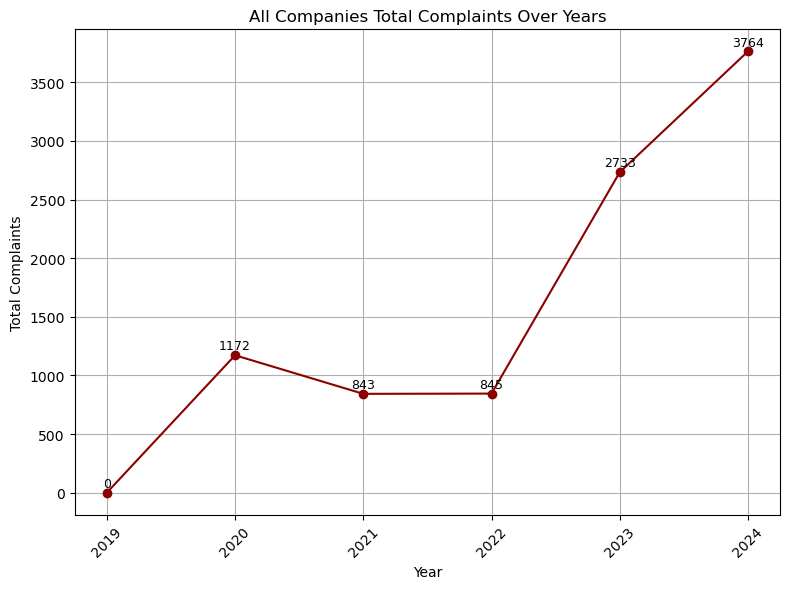

In [22]:
# Group and sum complaints by year all companies
# EDA

yearly_complaints = df.groupby('Year')['Total_Complaints'].sum().reset_index()

plt.figure(figsize=(8, 6))
plt.plot(yearly_complaints['Year'], yearly_complaints['Total_Complaints'], marker='o', color='darkred')
plt.title('All Companies Total Complaints Over Years')
plt.xlabel('Year')
plt.ylabel('Total Complaints')
plt.grid(True)
plt.xticks(rotation=45)
# add value labels at each point
for i in range(len(yearly_complaints)):
    x = yearly_complaints['Year'][i]
    y = yearly_complaints['Total_Complaints'][i]
    plt.text(x, y + 50, f'{int(y)}', ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

C:\Users\shopr\AppData\Local\Temp\ipykernel_29704\671494320.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Total_Complaints', data=yearly_complaints, palette='Reds')


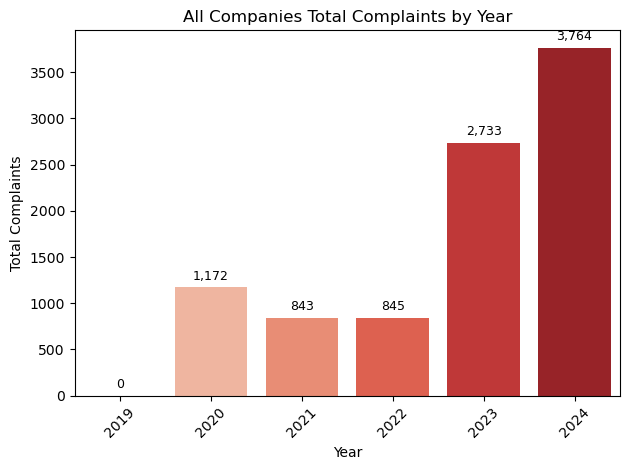

In [23]:
# Bar graph for all companies
# EDA

sns.barplot(x='Year', y='Total_Complaints', data=yearly_complaints, palette='Reds')
# Add value labels on top of each bar
for i, row in yearly_complaints.iterrows():
    plt.text(
        x=i,
        y=row['Total_Complaints'] + 50,  # adjust vertical position
        s=f'{int(row["Total_Complaints"]):,}',  # format with commas
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.title('All Companies Total Complaints by Year')
plt.xlabel('Year')
plt.ylabel('Total Complaints')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

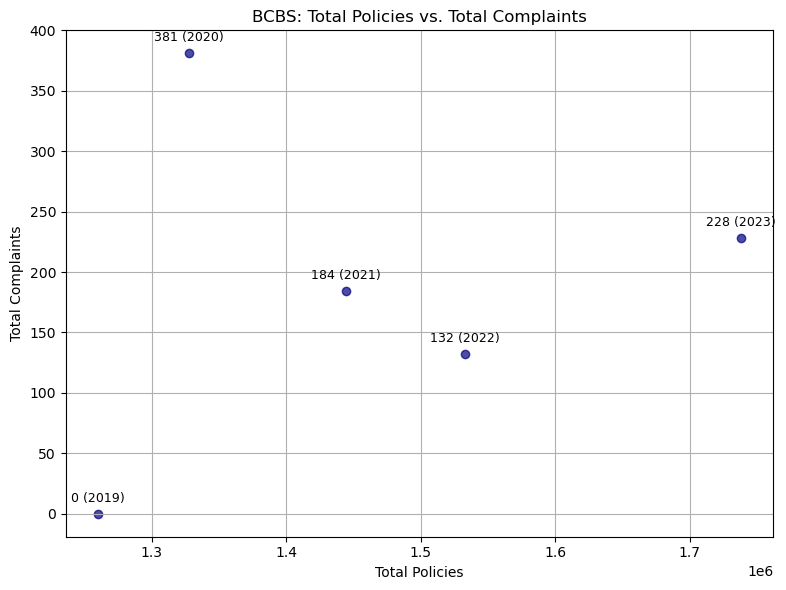

In [24]:
# BCBS Total Policies vs. Total Complaint Scatter plot 
#EDA

bcbs_df = df[df['Company name'] == 'BCBS']
plt.figure(figsize=(8, 6))
plt.scatter(bcbs_df['Total policies'], bcbs_df['Total_Complaints'], color='navy', alpha=0.7)
# Add value labels at each point
for i in range(len(bcbs_df)):
    x = bcbs_df['Total policies'].iloc[i]
    y = bcbs_df['Total_Complaints'].iloc[i]
    year = bcbs_df['Year'].iloc[i]
    plt.text(x, y + 10, f'{int(y)} ({year})', ha='center', fontsize=9, color='black')
plt.title('BCBS: Total Policies vs. Total Complaints')
plt.xlabel('Total Policies')
plt.ylabel('Total Complaints')
plt.grid(True)
plt.tight_layout()
plt.show()

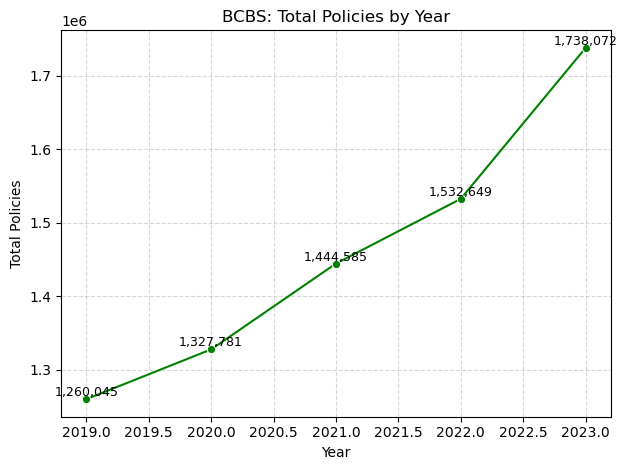

In [25]:
# Total Policies and Years line graph

sns.lineplot(x='Year', y='Total policies', data=bcbs_df, marker='o', color='green')

# Annotate each point with its value
for i, row in bcbs_df.reset_index().iterrows():
    plt.text(
        x=row['Year'],
        y=row['Total policies'] + 10,  # adjust vertical position
        s=f'{int(row["Total policies"]):,}',  # format with commas
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.title('BCBS: Total Policies by Year')
plt.xlabel('Year')
plt.ylabel('Total Policies')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

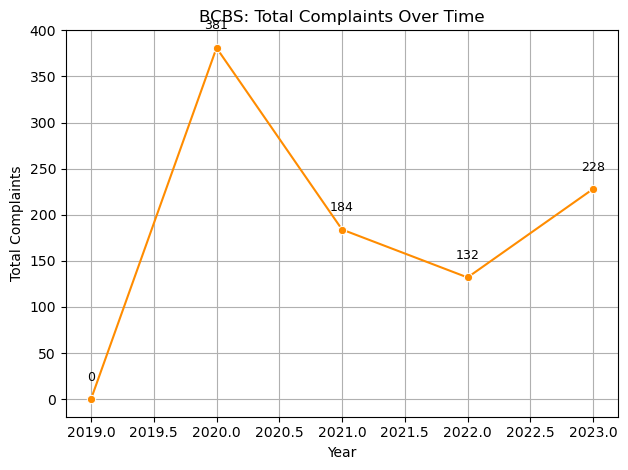

In [26]:
#  BCBS trend Over Time

sns.lineplot(x='Year', y='Total_Complaints', data=bcbs_df, marker='o', color='darkorange')
# Add value labels at each point
for i in range(len(bcbs_df)):
    x = bcbs_df['Year'].iloc[i]
    y = bcbs_df['Total_Complaints'].iloc[i]
    plt.text(x, y + 20, f'{int(y)}', ha='center', fontsize=9, color='black')
plt.title('BCBS: Total Complaints Over Time')
plt.xlabel('Year')
plt.ylabel('Total Complaints')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\shopr\AppData\Local\Temp\ipykernel_29704\380858582.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Total_Complaints', data=bcbs_df, palette='Oranges')


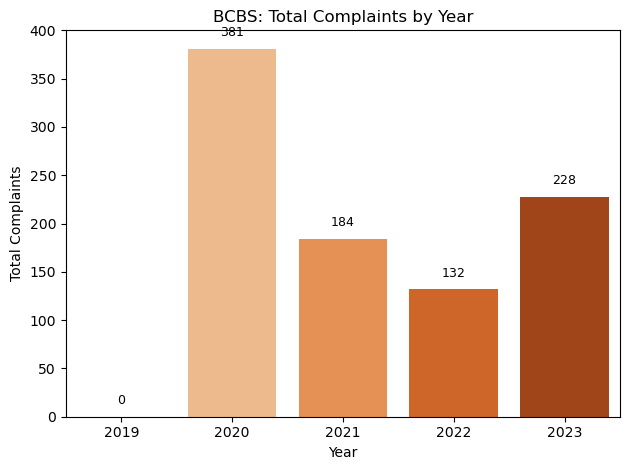

In [27]:
#  BCBS Yearly Comparison
# EDA

sns.barplot(x='Year', y='Total_Complaints', data=bcbs_df, palette='Oranges')
# Add value labels on top of each bar
for i, row in bcbs_df.reset_index().iterrows():
    plt.text(
        x=i,
        y=row['Total_Complaints'] + 10,  # adjust vertical position
        s=f'{int(row["Total_Complaints"]):,}',  # format with commas
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )
plt.title('BCBS: Total Complaints by Year')
plt.xlabel('Year')
plt.ylabel('Total Complaints')
plt.tight_layout()
plt.show()

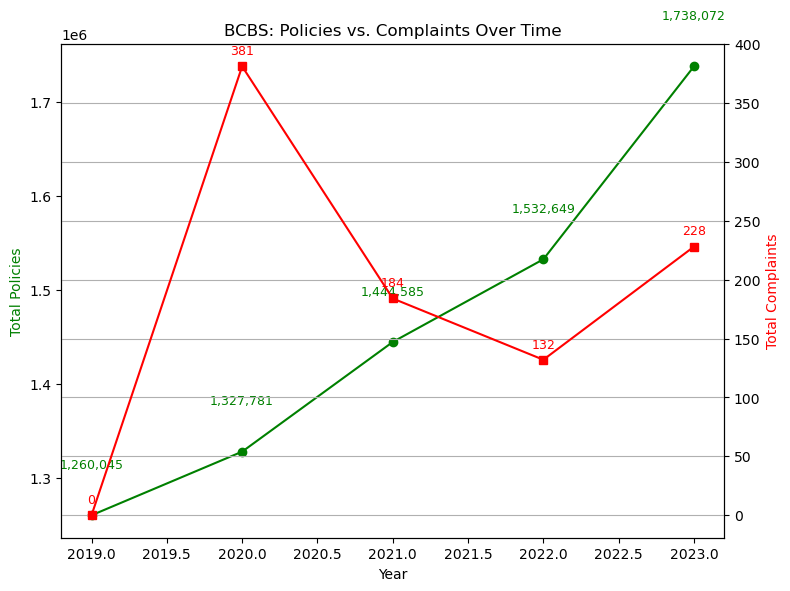

In [28]:
# Policies vs Complaints Together
# EDA

fig, ax1 = plt.subplots(figsize=(8, 6))

ax2 = ax1.twinx()
ax1.plot(bcbs_df['Year'], bcbs_df['Total policies'], color='green', marker='o', label='Total Policies')
ax2.plot(bcbs_df['Year'], bcbs_df['Total_Complaints'], color='red', marker='s', label='Total Complaints')
# Add value labels for Total Policies
for i in range(len(bcbs_df)):
    x = bcbs_df['Year'].iloc[i]
    y1 = bcbs_df['Total policies'].iloc[i]
    ax1.text(x, y1 + 50000, f'{y1:,}', color='green', ha='center', fontsize=9)

# Add value labels for Total Complaints
for i in range(len(bcbs_df)):
    x = bcbs_df['Year'].iloc[i]
    y2 = bcbs_df['Total_Complaints'].iloc[i]
    ax2.text(x, y2 + 10, f'{int(y2)}', color='red', ha='center', fontsize=9)
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Policies', color='green')
ax2.set_ylabel('Total Complaints', color='red')
plt.title('BCBS: Policies vs. Complaints Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

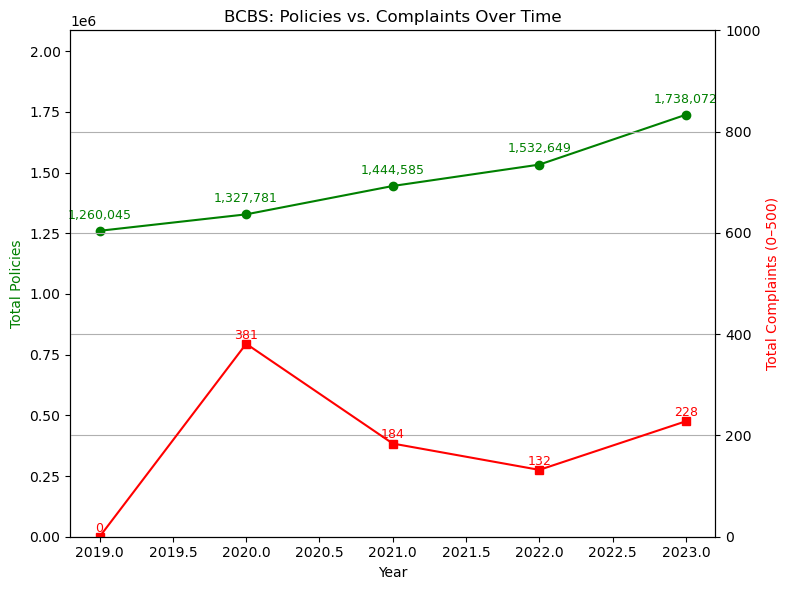

In [38]:
# Adjust graph for Policies vs Complaints Together for better representation
# EDA

fig, ax1 = plt.subplots(figsize=(8, 6))
ax2 = ax1.twinx()

# Plot Total Policies (primary y-axis)
ax1.plot(bcbs_df['Year'], bcbs_df['Total policies'], color='green', marker='o', label='Total Policies')

# Plot Total Complaints (secondary y-axis)
ax2.plot(bcbs_df['Year'], bcbs_df['Total_Complaints'], color='red', marker='s', label='Total Complaints')

# Set y-axis limits
ax1.set_ylim(0, bcbs_df['Total policies'].max() * 1.2)
ax2.set_ylim(0, 1000)  # Force complaints axis to max out at 500

# Add value labels for Total Policies
for i in range(len(bcbs_df)):
    x = bcbs_df['Year'].iloc[i]
    y1 = bcbs_df['Total policies'].iloc[i]
    ax1.text(x, y1 + 50000, f'{y1:,}', color='green', ha='center', fontsize=9)

# Add value labels for Total Complaints
for i in range(len(bcbs_df)):
    x = bcbs_df['Year'].iloc[i]
    y2 = bcbs_df['Total_Complaints'].iloc[i]
    ax2.text(x, y2 + 10, f'{int(y2)}', color='red', ha='center', fontsize=9)

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Policies', color='green')
ax2.set_ylabel('Total Complaints (0–500)', color='red')
plt.title('BCBS: Policies vs. Complaints Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# Calculate BCBS Complaint Index
# Feature Engineering
# Complait Index equal (company's percentage of confirmed complaints) / (company's percentage of policies in force)

# Get Total for the year
year_df = df[df['Year'] == 2020]
total_complaints = year_df['Total_Complaints'].sum()
total_policies = year_df['Total policies'].sum()
print(total_complaints)
print(total_policies)

1172.0
40120813


In [31]:
# Get BCBS specific values
company_df = year_df[year_df['Company name'] == 'BCBS']
company_complaints = company_df['Total_Complaints'].sum()
company_policies = company_df['Total policies'].sum()
print(company_complaints)
print(company_policies)

381.0
1327781


In [32]:
# Calculate percentages 

complaint_pct = company_complaints / total_complaints
policy_pct = company_policies / total_policies
print(complaint_pct)
print(policy_pct)

0.3250853242320819
0.03309456864695139


In [33]:
# Calculate complaint index

complaint_index = complaint_pct / policy_pct
print(complaint_index)

9.822920724546991


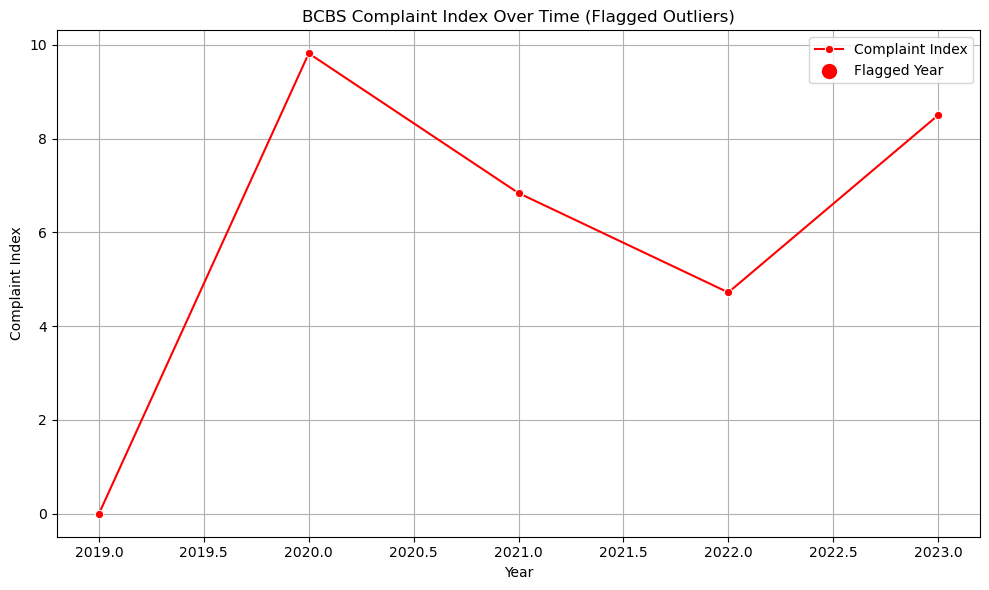

In [34]:
# Visualize BCBS Complaint Index year by year with a line plot

# Step 1: Filter BCBS data
bcbs_df = df[df['Company name'] == 'BCBS']

# Step 2: Calculate yearly Complaint Index
yearly_indexes = []
for year in bcbs_df['Year'].unique():
    year_df = df[df['Year'] == year]
    bcbs_year = bcbs_df[bcbs_df['Year'] == year]

    total_complaints = year_df['Total_Complaints'].sum()
    total_policies = year_df['Total policies'].sum()
    bcbs_complaints = bcbs_year['Total_Complaints'].sum()
    bcbs_policies = bcbs_year['Total policies'].sum()

    complaint_pct = bcbs_complaints / total_complaints if total_complaints else 0
    policy_pct = bcbs_policies / total_policies if total_policies else 0
    index = complaint_pct / policy_pct if policy_pct else 0

    yearly_indexes.append({'Year': year, 'Complaint Index': round(index, 2)})

index_df = pd.DataFrame(yearly_indexes).sort_values('Year')

# Step 3: Flag unusually high years
avg_index = index_df['Complaint Index'].mean()
std_index = index_df['Complaint Index'].std()
index_df['Flag'] = index_df['Complaint Index'] > (avg_index + std_index)

plt.figure(figsize=(10, 6))
sns.lineplot(data=index_df, x='Year', y='Complaint Index', marker='o', label='Complaint Index', color='red')

# Highlight flagged years
highlighted = index_df[index_df['Flag']]
plt.scatter(highlighted['Year'], highlighted['Complaint Index'], color='red', s=100, label='Flagged Year')

# Annotate flagged points
for _, row in highlighted.iterrows():
    plt.text(row['Year'], row['Complaint Index'] + 0.1, f"{row['Year']}", ha='center', color='red')

plt.title('BCBS Complaint Index Over Time (Flagged Outliers)')
plt.xlabel('Year')
plt.ylabel('Complaint Index')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

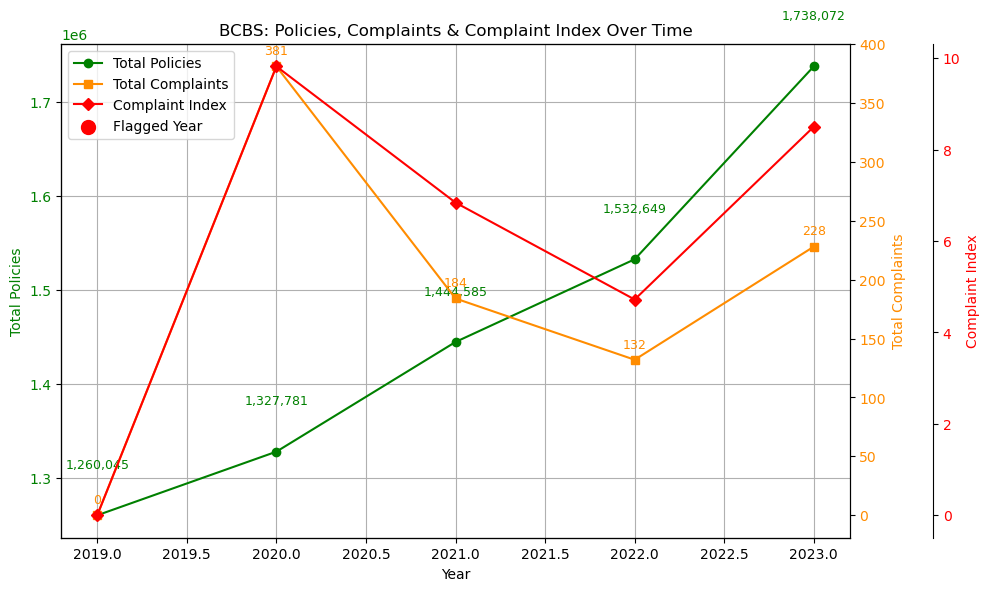

In [35]:
# overlap line graphs

fig, ax1 = plt.subplots(figsize=(10, 6))

# Second y-axis for Complaints
ax2 = ax1.twinx()

# Third y-axis for Complaint Index (overlayed)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))  # Offset to avoid overlap
ax3.set_frame_on(True)
ax3.patch.set_visible(False)

# --- Plot Total Policies ---

ax1.plot(bcbs_df['Year'], bcbs_df['Total policies'], color='green', marker='o', label='Total Policies')
for i in range(len(bcbs_df)):
    x = bcbs_df['Year'].iloc[i]
    y1 = bcbs_df['Total policies'].iloc[i]
    ax1.text(x, y1 + 50000, f'{y1:,}', color='green', ha='center', fontsize=9)

# --- Plot Total Complaints ---
ax2.plot(bcbs_df['Year'], bcbs_df['Total_Complaints'], color='darkorange', marker='s', label='Total Complaints')
for i in range(len(bcbs_df)):
    x = bcbs_df['Year'].iloc[i]
    y2 = bcbs_df['Total_Complaints'].iloc[i]
    ax2.text(x, y2 + 10, f'{int(y2)}', color='darkorange', ha='center', fontsize=9)

# --- Plot Complaint Index ---

ax3.plot(index_df['Year'], index_df['Complaint Index'], color='red', marker='D', label='Complaint Index')
highlighted = index_df[index_df['Flag']]
ax3.scatter(highlighted['Year'], highlighted['Complaint Index'], color='red', s=100, label='Flagged Year')
for _, row in highlighted.iterrows():
    ax3.text(row['Year'], row['Complaint Index'] + 0.1, f"{row['Year']}", ha='center', color='red')

# --- Axis Labels ---
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Policies', color='green')
ax2.set_ylabel('Total Complaints', color='darkorange')
ax3.set_ylabel('Complaint Index', color='red')

# --- Tick Colors ---
ax1.tick_params(axis='y', labelcolor='green')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax3.tick_params(axis='y', labelcolor='red')

# --- Title and Grid ---
plt.title('BCBS: Policies, Complaints & Complaint Index Over Time')
ax1.grid(True)

# --- Legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_3, labels_3 = ax3.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2 + lines_3, labels_1 + labels_2 + labels_3, loc='upper left')

plt.tight_layout()
plt.show()

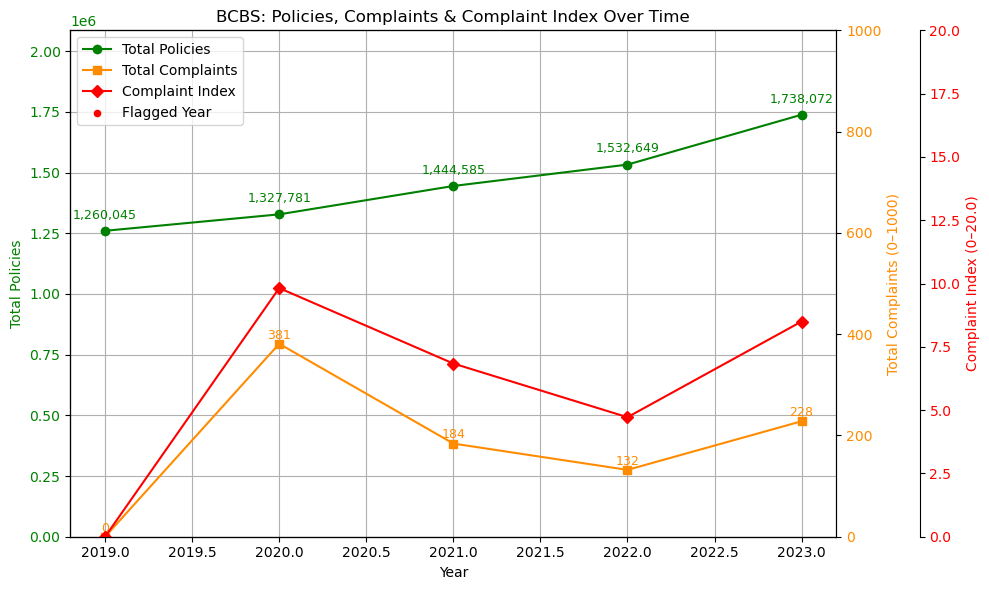

In [43]:
# Adjust overlap line graphs

fig, ax1 = plt.subplots(figsize=(10, 6))

# Second y-axis for Complaints
ax2 = ax1.twinx()

# Third y-axis for Complaint Index (overlayed)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))  # Offset to avoid overlap
ax3.set_frame_on(True)
ax3.patch.set_visible(False)

# --- Plot Total Policies ---
ax1.plot(bcbs_df['Year'], bcbs_df['Total policies'], color='green', marker='o', label='Total Policies')
for i in range(len(bcbs_df)):
    x = bcbs_df['Year'].iloc[i]
    y1 = bcbs_df['Total policies'].iloc[i]
    ax1.text(x, y1 + 50000, f'{y1:,}', color='green', ha='center', fontsize=9)

# --- Plot Total Complaints ---
ax2.plot(bcbs_df['Year'], bcbs_df['Total_Complaints'], color='darkorange', marker='s', label='Total Complaints')
for i in range(len(bcbs_df)):
    x = bcbs_df['Year'].iloc[i]
    y2 = bcbs_df['Total_Complaints'].iloc[i]
    ax2.text(x, y2 + 10, f'{int(y2)}', color='darkorange', ha='center', fontsize=9)

# --- Plot Complaint Index ---
ax3.plot(index_df['Year'], index_df['Complaint Index'], color='red', marker='D', label='Complaint Index')
highlighted = index_df[index_df['Flag']]
ax3.scatter(highlighted['Year'], highlighted['Complaint Index'], color='red', s=20, label='Flagged Year')
for _, row in highlighted.iterrows():
    ax3.text(row['Year'], row['Complaint Index'] + 0.1, f"{row['Year']}", ha='center', color='red')

# --- Axis Limits ---
ax1.set_ylim(0, bcbs_df['Total policies'].max() * 1.2)
ax2.set_ylim(0, 1000)  # Keep complaints visually below policies
ax3.set_ylim(0, 20.0)  # Scale index to stay below policies line

# --- Axis Labels ---
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Policies', color='green')
ax2.set_ylabel('Total Complaints (0–1000)', color='darkorange')
ax3.set_ylabel('Complaint Index (0–20.0)', color='red')

# --- Tick Colors ---
ax1.tick_params(axis='y', labelcolor='green')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax3.tick_params(axis='y', labelcolor='red')

# --- Title and Grid ---
plt.title('BCBS: Policies, Complaints & Complaint Index Over Time')
ax1.grid(True)

# --- Legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_3, labels_3 = ax3.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2 + lines_3, labels_1 + labels_2 + labels_3, loc='upper left')

plt.tight_layout()
plt.show()

In [36]:
# Complaint Index
''' The complaint index is calculated by dividing the company's percentage of complaints for a specific line of insurance
    by the company's percentage of policies in force for the same line of insurance.
    The average index is 1.00.
    A number less than 1 indicates fewer complaints than average.
    A number greater than 1 indicates more complaints than average. 
    Complaint Index is one of several indicators use to determine if an insurer should be investiged.
    The higher the Complaint Index the more attention is brought to the insurer.'''

" The complaint index is calculated by dividing the company's percentage of complaints for a specific line of insurance\n    by the company's percentage of policies in force for the same line of insurance.\n    The average index is 1.00.\n    A number less than 1 indicates fewer complaints than average.\n    A number greater than 1 indicates more complaints than average. \n    Complaint Index is one of several indicators use to determine if an insurer should be investiged.\n    The higher the Complaint Index the more attention is brought to the insurer."